# scVI with Scanpy (CPU)

This notebook pools `03_tissue_filtered.h5ad` files across one run directory, trains an scVI model on the combined object, then computes neighbors, UMAP, Leiden, and MDE using Scanpy CPU operations. The output filename remains `05_scvi.h5ad` so the existing downstream cell-typing notebook can keep reading the same path.

In [2]:
from __future__ import annotations

import argparse
import gc
import importlib
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import sys
import textwrap
import scvi

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

PROCESSING_DIR = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex").expanduser()
HELPER_PATH = PROCESSING_DIR / "04_scvi.py"

spec = importlib.util.spec_from_file_location("scvi_helper", HELPER_PATH)
scvi_helper = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = scvi_helper
spec.loader.exec_module(scvi_helper)

HELPER_PATH

/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/04_scvi.py')

In [3]:
import scvi
print('scvi file:', scvi.__file__)
print('scvi version:', getattr(scvi, '__version__', 'unknown'))
print('has scvi.model:', hasattr(scvi, 'model'))
print('has scvi.set_seed:', hasattr(scvi, 'set_seed'))
print('available scvi attrs:', [a for a in dir(scvi) if a in {'model', 'set_seed', '__version__'} or 'settings' in a.lower() or 'model' in a.lower()])

scvi file: /opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scvi/__init__.py
scvi version: 1.4.2
has scvi.model: True
has scvi.set_seed: False
available scvi attrs: ['__version__', '_settings', 'model', 'settings']


In [4]:
from pathlib import Path

input_path = "/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/03_Remove_bad_tissues"
input_name = "03_tissue_filtered.h5ad"

input_path_resolved = Path(input_path).expanduser().resolve()
input_folders = scvi_helper.resolve_input_folders(input_path_resolved, input_name)

output_dir = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI")
output_name = "05_scvi.h5ad"
n_latent = 30
n_layers = 2
gene_likelihood = "nb" # scvi gene_likelihood parameter
max_epochs = None
n_neighbors = 15
leiden_resolution = 1.0
neighbors_key = "scvi"
random_seed = 0

## Dependencies

This notebook uses scvi-tools for VAE training and Scanpy for clustering. No RAPIDS or GPU acceleration is required.

In [5]:
def package_version(distribution: str) -> str:
    try:
        return version(distribution)
    except PackageNotFoundError:
        return "unknown"

## Path helpers

The scVI step pools all filtered objects from one run into a single combined AnnData. Outputs are written under a `combined` directory beside the run.

In [6]:
def experiment_has_input(experiment_dir: Path, input_name: str) -> bool:
    return (experiment_dir / "adatas" / input_name).exists()


def resolve_input_folders(input_path: Path, input_name: str) -> list[Path]:
    if experiment_has_input(input_path, input_name):
        return [input_path]

    input_folders = sorted(
        path for path in input_path.iterdir() if path.is_dir() and experiment_has_input(path, input_name)
    )
    if input_folders:
        return input_folders

    raise FileNotFoundError(
        f"Could not find any experiment with adatas/{input_name} at or under {input_path}"
    )


def resolve_run_dir(input_path: Path, input_folders: list[Path]) -> Path:
    if len(input_folders) == 1 and input_path == input_folders[0]:
        return input_folders[0].parent

    return input_path


def resolve_output_dir(
    input_path: Path,
    input_folders: list[Path],
    output_dir: str | None,
) -> Path:
    if output_dir is not None:
        return Path(output_dir).expanduser().resolve()

    return resolve_run_dir(input_path, input_folders) / "combined"

def duplicated_row_mask(matrix) -> np.ndarray:
    values = np.asarray(matrix)
    if values.ndim != 2 or values.shape[0] == 0:
        return np.zeros(values.shape[0], dtype=bool)

    row_view = np.ascontiguousarray(values).view(
        np.dtype((np.void, values.dtype.itemsize * values.shape[1]))
    ).reshape(-1)
    _, inverse, counts = np.unique(row_view, return_inverse=True, return_counts=True)
    return np.asarray(counts[inverse] > 1, dtype=bool).reshape(-1)

## Input loading

Each experiment is tagged with its folder name in `obs['batch']`. The cell barcodes are prefixed with the batch name before concatenation so the pooled object does not inherit duplicate observation names.

In [7]:
def load_single_input(experiment_dir: Path, input_name: str):
    adata = sc.read_h5ad(experiment_dir / "adatas" / input_name)
    batch_name = experiment_dir.name

    adata = adata.copy()
    adata.obs["batch"] = batch_name
    adata.obs_names = [f"{batch_name}:{obs_name}" for obs_name in adata.obs_names]
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    print(f"Loaded {experiment_dir.name}: shape {adata.shape}, batch '{batch_name}'")
    return adata


def load_pooled_adata(input_folders: list[Path], input_name: str):
    adatas = []

    for experiment_dir in input_folders:
        print(f"Loading {experiment_dir}")
        adatas.append(load_single_input(experiment_dir, input_name))

    adata = sc.concat(
        adatas,
        join="outer",
        fill_value=0,
        merge="same",
        uns_merge="same",
    )
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    return adata

In [9]:
# Load and pool the adatas
input_path_resolved = Path(input_path).expanduser().resolve()
input_folders = resolve_input_folders(input_path_resolved, input_name)
output_dir_resolved = resolve_output_dir(input_path_resolved, input_folders, output_dir)
output_dir_resolved.mkdir(parents=True, exist_ok=True)

adata = load_pooled_adata(input_folders, input_name)
print(f"Pooled shape: {adata.shape}")
print(f"Batches: {adata.obs['batch'].unique()}")

# # Subset the AnnData object for quick testing
# n_test_cells = 1000
# if adata.n_obs > n_test_cells:
#     adata = adata[adata.obs.sample(n=n_test_cells, random_state=random_seed).index].copy()
#     print(f"Subset shape for testing: {adata.shape}")
# else:
#     print(f"Using full dataset for testing: {adata.shape}")
print(adata.shape)
adata.write("04_merged_adata.h5ad", compression='gzip')


Loading /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/03_Remove_bad_tissues/AD_inf
Loaded AD_inf: shape (55417, 480), batch 'AD_inf'
Loading /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/03_Remove_bad_tissues/AD_mock
Loaded AD_mock: shape (64377, 480), batch 'AD_mock'
Loading /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/03_Remove_bad_tissues/reference_ln
Loaded reference_ln: shape (38318, 480), batch 'reference_ln'
Pooled shape: (158112, 480)
Batches: ['AD_inf' 'AD_mock' 'reference_ln']
(158112, 480)


## scVI training

The pooled object is used to train one model across batches. The count matrix is copied into `adata.layers['counts']` so scVI uses raw counts consistently.

In [11]:
def train_scvi_model(adata, n_latent, n_layers, gene_likelihood, max_epochs, random_seed):
    import os
    import torch

    print("train_scvi_model: torch.cuda.is_available()=", torch.cuda.is_available())
    print("train_scvi_model: CUDA_VISIBLE_DEVICES=", os.environ.get("CUDA_VISIBLE_DEVICES"))

    if not hasattr(scvi, "model"):
        raise ImportError(
            "The imported scvi package does not contain scvi.model. "
            "Install scvi-tools in the current notebook kernel with `%pip install scvi-tools` "
            "or switch to a Python environment where scvi-tools is installed."
        )

    scvi.settings.seed = random_seed
    adata.layers["counts"] = adata.X.copy()

    scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
    vae = scvi.model.SCVI(
        adata,
        n_layers=n_layers,
        n_latent=n_latent,
        gene_likelihood=gene_likelihood,
    )

    train_kwargs = {}
    if max_epochs is not None:
        train_kwargs["max_epochs"] = max_epochs
    if torch.cuda.is_available():
        train_kwargs["accelerator"] = "gpu"
        train_kwargs["devices"] = 1

    vae.train(**train_kwargs)
    adata.obsm["X_scVI"] = vae.get_latent_representation()
    del vae
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return adata


In [12]:
import scvi
# Train scVI model
adata = train_scvi_model(adata, n_latent, n_layers, gene_likelihood, max_epochs, random_seed)
print(f"scVI latent shape: {adata.obsm['X_scVI'].shape}")

Seed set to 0
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `i

train_scvi_model: torch.cuda.is_available()= False
train_scvi_model: CUDA_VISIBLE_DEVICES= None
Epoch 51/51: 100%|██████████| 51/51 [09:40<00:00, 10.78s/it, v_num=1, train_loss=243]

`Trainer.fit` stopped: `max_epochs=51` reached.


Epoch 51/51: 100%|██████████| 51/51 [09:40<00:00, 11.39s/it, v_num=1, train_loss=243]
scVI latent shape: (158112, 30)


## Graph construction and embedding

Using Scanpy CPU operations to compute neighbors, UMAP, Leiden clustering, and MDE embedding from the scVI latent space.

In [ ]:
def build_mde_representation(matrix, random_seed: int):
    values = np.asarray(matrix)
    duplicate_mask = duplicated_row_mask(values)
    duplicated_rows = int(np.count_nonzero(duplicate_mask))

    if duplicated_rows == 0:
        return values, {
            "status": "cpu_mde",
            "duplicated_latent_rows": 0,
            "mde_use_rep": "X_scVI",
            "jitter_scale": 0.0,
        }

    jittered = values.copy()
    finite_values = np.asarray(values, dtype=np.float32)
    feature_scale = np.std(finite_values, axis=0)
    positive_scale = feature_scale[feature_scale > 0]
    base_scale = float(np.median(positive_scale)) if positive_scale.size else 1.0
    jitter_scale = max(base_scale * 1e-4, 1e-7)

    rng = np.random.default_rng(random_seed)
    noise = rng.normal(
        loc=0.0,
        scale=jitter_scale,
        size=(duplicated_rows, values.shape[1])).astype(values.dtype, copy=False)
    jittered[duplicate_mask] = jittered[duplicate_mask] + noise

    return jittered, {
        "status": "cpu_mde_jittered_duplicates",
        "duplicated_latent_rows": duplicated_rows,
        "mde_use_rep": "X_scVI_mde",
        "jitter_scale": float(jitter_scale),
    }


def run_mde_on_cpu(adata, use_rep: str, n_neighbors: int):
    try:
        import pymde
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Missing dependency 'pymde'. Install it with `%pip install pymde` and re-run this cell. "
            "If you cannot install pymde, run Scanpy UMAP only and skip MDE by commenting out the MDE call."
        ) from exc

    data = adata.obsm[use_rep]
    if hasattr(data, "values"):
        data = data.values
    data = np.asarray(data)

    emb = pymde.preserve_neighbors(
        data,
        embedding_dim=2,
        constraint=pymde.Standardized(),
        repulsive_fraction=0.7,
        init="random",
        verbose=False,
        device="cpu",
        n_neighbors=n_neighbors,
    ).embed(verbose=False)

    if hasattr(emb, "cpu"):
        emb = emb.cpu().numpy()
    adata.obsm["X_mde"] = np.asarray(emb)


In [14]:
def run_scanpy_cpu(adata, n_neighbors, leiden_resolution, neighbors_key, random_seed):
    """Compute neighbors, UMAP, Leiden clustering, and MDE using CPU Scanpy."""
    # Compute neighbors on scVI latent space
    sc.pp.neighbors(
        adata,
        use_rep="X_scVI",
        n_neighbors=n_neighbors,
        key_added=neighbors_key,
        random_state=random_seed,
    )
    
    # UMAP embedding
    sc.tl.umap(adata, neighbors_key=neighbors_key, random_state=random_seed)
    
    # Leiden clustering
    sc.tl.leiden(
        adata,
        neighbors_key=neighbors_key,
        resolution=leiden_resolution,
        random_state=random_seed,
        key_added="leiden",
    )
    
    # Run MDE on CPU
    mde_representation, mde_status = build_mde_representation(
        adata.obsm["X_scVI"],
        random_seed,
    )
    if mde_status["mde_use_rep"] == "X_scVI_mde":
        print(
            "Detected "
            f"{mde_status['duplicated_latent_rows']} duplicated rows in X_scVI; "
            "running CPU MDE on a lightly jittered copy in X_scVI_mde."
        )
        adata.obsm["X_scVI_mde"] = mde_representation
        run_mde_on_cpu(
            adata,
            use_rep="X_scVI_mde",
            n_neighbors=n_neighbors,
        )
        if "X_scVI_mde" in adata.obsm:
            del adata.obsm["X_scVI_mde"]
    else:
        print("Running CPU MDE on X_scVI.")
        run_mde_on_cpu(
            adata,
            use_rep="X_scVI",
            n_neighbors=n_neighbors,
        )
    
    final_mde_status = {
        "status": (
            "cpu_mde_jittered_duplicates"
            if mde_status["mde_use_rep"] != "X_scVI"
            else "cpu_mde"
        ),
        "duplicated_latent_rows": int(mde_status["duplicated_latent_rows"]),
        "mde_use_rep": str(mde_status["mde_use_rep"]),
        "jitter_scale": float(mde_status["jitter_scale"]),
        "backend": "scanpy_cpu",
    }
    
    return adata, final_mde_status

In [15]:
# Run Scanpy CPU for neighbors, UMAP, and Leiden
adata, final_mde_status = run_scanpy_cpu(
    adata,
    n_neighbors,
    0.5,
    neighbors_key,
    random_seed
)
print(f"Leiden resolution: {leiden_resolution}")
print(f"Number of clusters: {len(adata.obs['leiden'].unique())}")
print(f"Backend: {final_mde_status['backend']}")


/var/folders/82/6l796mmn2fj1pv97hrt8rh1h0000gp/T/ipykernel_50763/2840022904.py:16: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Running CPU MDE on X_scVI.
Leiden resolution: 1.0
Number of clusters: 17
Backend: scanpy_cpu


## Checkpoint: Adjust Leiden Resolution

You can adjust the `leiden_resolution` parameter below and re-run the Leiden clustering to see different cluster separations. The neighbors and UMAP are already computed, so this is fast.


In [16]:
adata.layers["counts"].shape

(158112, 480)

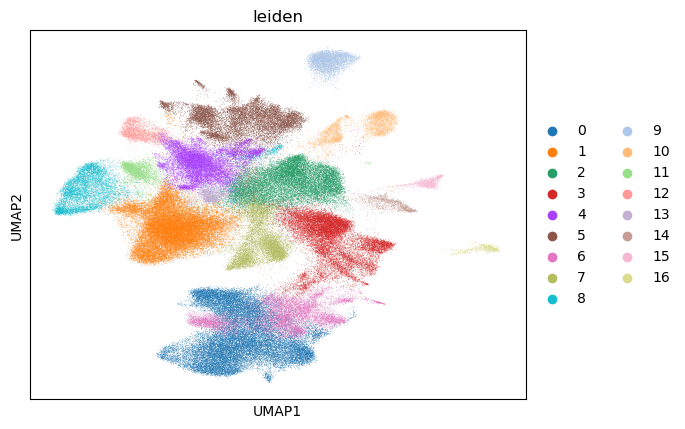

In [17]:
sc.pl.umap(adata, color="leiden")

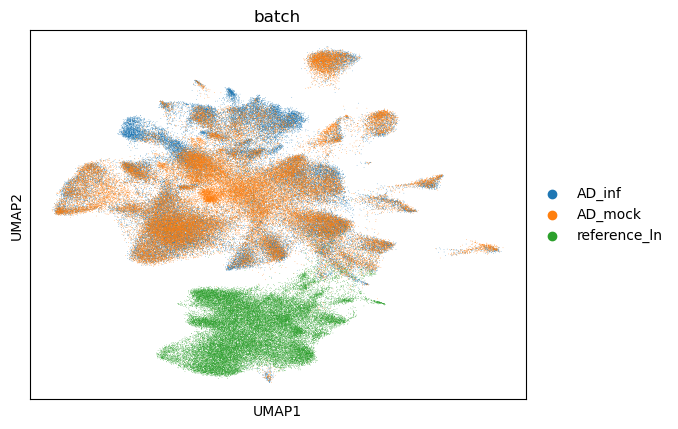

In [18]:
sc.pl.umap(adata, color="batch")

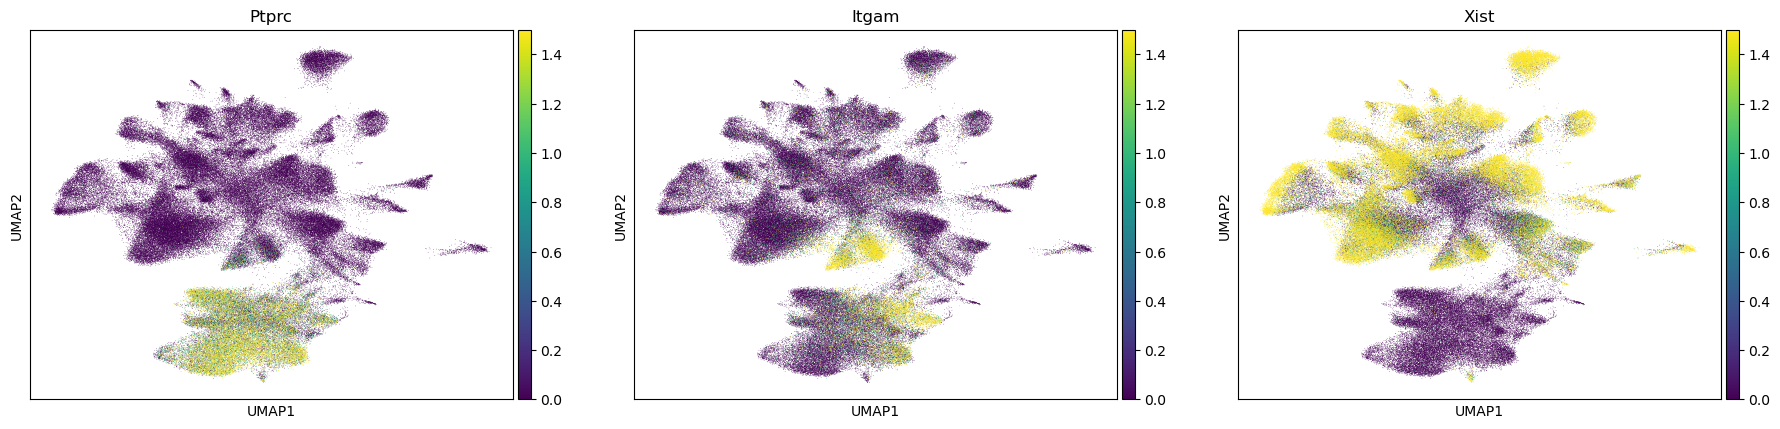

In [19]:
sc.pl.umap(adata, color=["Ptprc", "Itgam", "Xist"], vmin=0, vmax=1.5)

### Adjust Leiden resolution if needed

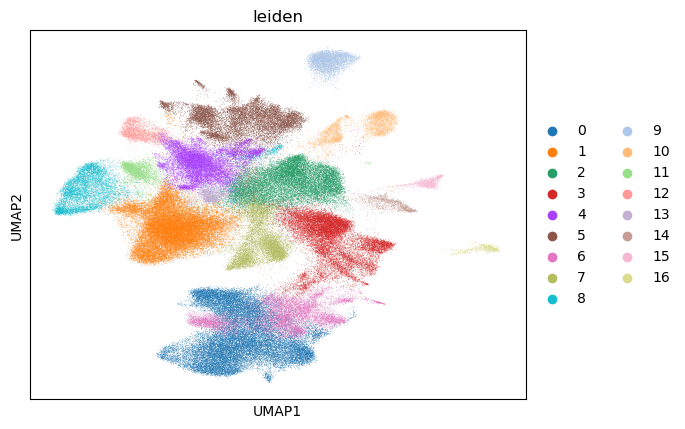

In [21]:
sc.pl.umap(adata, color="leiden")

## Output helpers

The old notebook displayed the embedding but did not save it. The script saves both a UMAP view and an MDE view. MDE is now generated through RAPIDS SingleCell too, which keeps `X_mde` available for downstream notebooks that already plot the MDE basis.

In [22]:
def save_umap_plot(adata, output_dir: Path) -> Path:
    figure_dir = output_dir / "figures" / "scvi"
    figure_dir.mkdir(parents=True, exist_ok=True)
    plot_path = figure_dir / "scvi_umap_batch_leiden.png"

    sc.pl.umap(adata, color=["batch", "leiden"], show=False)
    plt.gcf().savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close(plt.gcf())
    return plot_path


def save_mde_plot(adata, output_dir: Path) -> Path:
    figure_dir = output_dir / "figures" / "scvi"
    figure_dir.mkdir(parents=True, exist_ok=True)
    plot_path = figure_dir / "scvi_mde_batch_leiden.png"

    sc.pl.embedding(adata, basis="mde", color=["batch", "leiden"], show=False)
    plt.gcf().savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close(plt.gcf())
    return plot_path

In [23]:
def attach_metadata(
    adata,
    input_folders: list[Path],
    output_path: Path,
    umap_plot_path: Path,
    mde_plot_path: Path,
    mde_status: dict[str, int | str],
):
    adata.uns["scvi_input_folders"] = [str(path) for path in input_folders]
    adata.uns["scvi_output_path"] = str(output_path)
    adata.uns["scvi_umap_plot"] = str(umap_plot_path)
    adata.uns["scvi_mde_plot"] = str(mde_plot_path)
    adata.uns["scvi_parameters"] = {
        "input_name": input_name,
        "output_name": output_name,
        "n_latent": int(n_latent),
        "n_layers": int(n_layers),
        "gene_likelihood": str(gene_likelihood),
        "max_epochs": None if max_epochs is None else int(max_epochs),
        "n_neighbors": int(n_neighbors),
        "leiden_resolution": float(leiden_resolution),
        "neighbors_key": str(neighbors_key),
        "random_seed": int(random_seed),
    }
    adata.uns["scvi_runtime"] = {
        "scanpy_version": package_version("scanpy"),
        "scvi_tools_version": package_version("scvi-tools"),
        "rapids_singlecell_version": "unknown",
    }
    adata.uns["scvi_mde_status"] = mde_status
    return adata


In [24]:
# Save plots and output
umap_plot_path = save_umap_plot(adata, output_dir_resolved)
mde_plot_path = save_mde_plot(adata, output_dir_resolved)

output_path = output_dir_resolved / output_name
adata = attach_metadata(
    adata,
    input_folders,
    output_path,
    umap_plot_path,
    mde_plot_path,
    final_mde_status,
)
adata.write(output_path)

print(f"Wrote {output_path}")
print(f"Wrote {umap_plot_path}")
print(f"Wrote {mde_plot_path}")

Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/05_scvi.h5ad
Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/figures/scvi/scvi_umap_batch_leiden.png
Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/figures/scvi/scvi_mde_batch_leiden.png


In [ ]:
# T cell subset - define clusters that are T cells
# Update this list based on your leiden_0.5 clusters identified as T cells
# For example: tcell_clusters = ['0', '1', '6', '7', '11', '13', '24'] in original data
# Adjust based on marker expression

tcell_clusters = None  # Set this based on your analysis
# Example: tcell_clusters = ['1', '6', '7', '11', '13', '24']

if tcell_clusters is not None:
    adata_tcells = adata[adata.obs['leiden_0.5'].astype(str).isin([str(c) for c in tcell_clusters])].copy()
    print(f"Extracted {adata_tcells.n_obs} T cells from {len(tcell_clusters)} clusters")
    print(f"T cell cluster distribution: {adata_tcells.obs['leiden_0.5'].value_counts().sort_index()}")
else:
    print("⚠️ Define tcell_clusters list based on your marker analysis above")
    print("Example: tcell_clusters = ['0', '3', '5']  # Update based on your data")


In [ ]:
# Subclustering of T cells at higher resolution (if tcell_clusters was defined)
if tcell_clusters is not None and len(adata_tcells) > 0:
    # Recompute neighbors on T cells
    sc.pp.neighbors(
        adata_tcells,
        use_rep="X_scVI",
        n_neighbors=n_neighbors,
        key_added="tcell_scvi",
        random_state=random_seed,
    )
    
    # Compute UMAP for T cells
    sc.tl.umap(adata_tcells, neighbors_key="tcell_scvi", random_state=random_seed)
    
    # Leiden clustering at different resolutions
    for res in [0.3, 0.5, 0.8, 1.0]:
        sc.tl.leiden(
            adata_tcells,
            neighbors_key="tcell_scvi",
            resolution=res,
            random_state=random_seed,
            key_added=f"leiden_tcell_{res}",
        )
    
    print("Computed T cell subclustering and UMAP")
    print(f"T cell leiden_tcell_0.5 clusters: {sorted(adata_tcells.obs['leiden_tcell_0.5'].unique())}")
    
    # Plot T cells at different resolutions
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for i, res in enumerate([0.3, 0.5, 0.8, 1.0]):
        ax = axes.flat[i]
        sc.pl.umap(adata_tcells, color=f"leiden_tcell_{res}", ax=ax, show=False, title=f"T cells resolution={res}")
    plt.tight_layout()
    plt.show()


In [ ]:
# T cell marker analysis (if T cells were defined)
if tcell_clusters is not None and len(adata_tcells) > 0:
    # Find markers for T cell subclusters
    sc.tl.rank_genes_groups(
        adata_tcells,
        groupby="leiden_tcell_0.5",
        method="t-test",
        use_raw=False,
        n_genes=20,
        pts=False,
    )
    
    # Plot dot plot for T cell subclusters
    top_genes_tcells = adata_tcells.uns["rank_genes_groups"]["names"][:, :5].flatten()
    top_genes_tcells = [g for g in top_genes_tcells if g in adata_tcells.var_names]
    
    sc.pl.dotplot(
        adata_tcells,
        var_names=list(dict.fromkeys(top_genes_tcells)),
        groupby="leiden_tcell_0.5",
        figsize=(10, 6),
        show=False,
    )
    plt.tight_layout()
    plt.show()
    
    print("T cell marker analysis complete")
    print(f"T cell clusters: {sorted(adata_tcells.obs['leiden_tcell_0.5'].unique())}")


In [ ]:
# Save analysis results
print("Analysis Summary:")
print(f"Total cells: {adata.n_obs}")
print(f"Total genes: {adata.n_vars}")
print(f"Leiden clusters (res=1.0): {adata.obs['leiden'].nunique()}")
print(f"Leiden clusters (res=0.5): {adata.obs['leiden_0.5'].nunique()}")
if tcell_clusters is not None and len(adata_tcells) > 0:
    print(f"T cells: {adata_tcells.n_obs}")
    print(f"T cell subclusters (res=0.5): {adata_tcells.obs['leiden_tcell_0.5'].nunique()}")

# Save main object with leiden_0.5
adata.write(output_path, compression='gzip')
print(f"\n✅ Saved updated adata with leiden_0.5 to {output_path}")

# Optionally save T cell object
if tcell_clusters is not None and len(adata_tcells) > 0:
    tcell_path = output_dir_resolved / "tcells_leiden_0.5.h5ad"
    adata_tcells.write(tcell_path, compression='gzip')
    print(f"✅ Saved T cell subset to {tcell_path}")
